# 03 - Sproud + fórmula simbólica + gráficas

Este notebook:
1. Carga KAN entrenado y **features transformadas para KAN** (incluye PCA 95% si se aplicó en notebook 02).
2. Cachea activaciones internas.
3. Calcula importancia de aristas (estilo Sproud).
4. Ajusta funciones simbólicas por arista top.
5. Intenta graficar aristas; si falla, al menos deja fórmula simbólica global.

In [9]:
# Imports y configuración
from pathlib import Path
import sys
import json
import time

import pandas as pd
import torch
from kan import KAN

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "Prueba_emmbedings" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / "scripts"))
from kan_plot_utils import save_kan_edges_light

ARTIFACTS_DIR = ROOT / "Prueba_emmbedings" / "artifacts"
KAN_FEATURES_PATH = ARTIFACTS_DIR / "kan_features.pt"
KAN_WEIGHTS_PATH = ARTIFACTS_DIR / "kan_head.pt"
KAN_CFG_PATH = ARTIFACTS_DIR / "kan_config.json"

SPROUD_OUT = ARTIFACTS_DIR / "sproud_edges.csv"
SYMBOLIC_OUT = ARTIFACTS_DIR / "symbolic_edges.csv"
FORMULA_OUT = ARTIFACTS_DIR / "symbolic_formula.txt"
PLOT_OUT = ARTIFACTS_DIR / "sproud_edges_layer0.png"

DEVICE = torch.device("cpu")
SPROUD_LAYER = 0
SPROUD_TOP_K = 12
SYMBOLIC_CANDIDATES = 8
SYMBOLIC_R2_THRESHOLD = 0.0

# Salvaguardas para evitar cuelgues en búsquedas simbólicas largas.
SYMBOLIC_LIB = ["x", "x^2", "x^3", "abs", "sin", "exp", "log"]
SYMBOLIC_MAX_SECONDS = 180
RUN_AUTO_SYMBOLIC_FALLBACK = False

In [10]:
# Funciones auxiliares
def build_kan_from_cfg(cfg):
    return KAN(width=cfg["width"], grid=cfg["grid"], k=cfg["k"], auto_save=False, seed=cfg.get("seed", 42)).to(DEVICE)

def cache_activations(kan_model, X):
    with torch.no_grad():
        _ = kan_model(X)
    if hasattr(kan_model, "get_act"):
        kan_model.get_act(X)

def sproud_importance(kan_model, layer=0, top_k=12):
    sp = kan_model.spline_postacts[layer]  # [N, out, in]
    imp = sp.abs().mean(dim=0)            # [out, in]
    out_dim, in_dim = imp.shape
    flat = torch.argsort(imp.flatten(), descending=True).tolist()
    rows = []
    for rank, idx in enumerate(flat[:top_k], start=1):
        out_idx = idx // in_dim
        in_idx = idx % in_dim
        rows.append({
            "rank": rank,
            "layer": int(layer),
            "out_idx": int(out_idx),
            "in_idx": int(in_idx),
            "importance": float(imp[out_idx, in_idx].item()),
        })
    return pd.DataFrame(rows)

def symbolic_fit_for_edges(
    kan_model,
    edges_df,
    layer=0,
    topk=8,
    r2_threshold=0.0,
    lib=None,
    max_seconds=None,
):
    rows = []
    t0 = time.time()

    for n, (_, r) in enumerate(edges_df.iterrows(), start=1):
        if max_seconds is not None and (time.time() - t0) > max_seconds:
            print(f"Se alcanzó el límite de {max_seconds}s; se detiene ajuste simbólico local.")
            break

        in_idx = int(r["in_idx"])
        out_idx = int(r["out_idx"])
        before_name = None
        after_name = None
        best_name = None
        best_r2 = None
        best_c = None
        fixed = False
        error = ""

        t_edge = time.time()
        try:
            before_name = kan_model.symbolic_fun[layer].funs_name[out_idx][in_idx]
            best_name, _, best_r2, best_c = kan_model.suggest_symbolic(
                layer,
                in_idx,
                out_idx,
                lib=lib,
                topk=topk,
                verbose=False,
            )
            if best_name is not None and float(best_r2) >= r2_threshold:
                kan_model.fix_symbolic(layer, in_idx, out_idx, best_name, verbose=False, log_history=False)
                fixed = True
            after_name = kan_model.symbolic_fun[layer].funs_name[out_idx][in_idx]
        except Exception as e:
            error = repr(e)

        elapsed = time.time() - t_edge
        print(f"Arista {n}/{len(edges_df)} ({out_idx},{in_idx}) | {elapsed:.1f}s | best={best_name} r2={best_r2}")

        rows.append({
            "layer": layer,
            "out_idx": out_idx,
            "in_idx": in_idx,
            "importance": float(r["importance"]),
            "before_name": before_name,
            "best_symbolic": best_name,
            "best_r2": None if best_r2 is None else float(best_r2),
            "complexity": None if best_c is None else float(best_c),
            "fixed": bool(fixed),
            "after_name": after_name,
            "error": error,
        })

    return pd.DataFrame(rows)

In [11]:
# Cargar artifacts y construir KAN
cfg = json.loads(KAN_CFG_PATH.read_text(encoding="utf-8"))
data = torch.load(KAN_FEATURES_PATH, map_location="cpu")
Xva = data["X_val"].to(DEVICE).float()

kan_model = build_kan_from_cfg(cfg)
kan_model.load_state_dict(torch.load(KAN_WEIGHTS_PATH, map_location=DEVICE))
kan_model.eval()

cache_activations(kan_model, Xva)
print("Cache listo. spline_postacts[0]:", tuple(kan_model.spline_postacts[0].shape))
print("Input dim KAN:", int(Xva.shape[1]), "| use_pca:", cfg.get("use_pca", False), "| target_var:", cfg.get("pca_target_variance", None))

Cache listo. spline_postacts[0]: (549, 63, 252)
Input dim KAN: 252 | use_pca: True | target_var: 0.95


Sproud edges: G:\Cosas_programacion\Breast Cancer Interpretable-ml\Prueba_emmbedings\artifacts\sproud_edges.csv


,rank,layer,out_idx,in_idx,importance
0,1,0,3,2,0.186896
1,2,0,19,0,0.181310
2,3,0,21,0,0.169205
3,4,0,1,0,0.163897
4,5,0,8,2,0.160023
5,6,0,47,0,0.159673
6,7,0,15,2,0.159436
7,8,0,60,5,0.159241
8,9,0,34,2,0.156481
9,10,0,31,5,0.156064


Arista 1/12 (3,2) | 0.5s | best=x r2=0.7488714456558228
Arista 2/12 (19,0) | 0.5s | best=x r2=0.747665524482727
Arista 3/12 (21,0) | 0.6s | best=x r2=0.7457531690597534
Arista 4/12 (1,0) | 0.5s | best=x r2=0.749013364315033
Arista 5/12 (8,2) | 0.4s | best=x r2=0.7461785078048706
Arista 6/12 (47,0) | 0.4s | best=x r2=0.7468765377998352
Arista 7/12 (15,2) | 0.4s | best=x r2=0.7481045126914978
Arista 8/12 (60,5) | 0.4s | best=x r2=0.7300496697425842
Arista 9/12 (34,2) | 0.4s | best=x r2=0.7497960925102234
Arista 10/12 (31,5) | 0.4s | best=x r2=0.727965772151947
Arista 11/12 (32,5) | 0.5s | best=x r2=0.7320650219917297
Arista 12/12 (51,1) | 0.4s | best=x r2=0.7117412686347961
Symbolic edges: G:\Cosas_programacion\Breast Cancer Interpretable-ml\Prueba_emmbedings\artifacts\symbolic_edges.csv


,layer,out_idx,in_idx,importance,before_name,best_symbolic,best_r2,complexity,fixed,after_name,error,is_trivial
0,0,3,2,0.186896,0,x,0.748871,1.0,True,x,,False
1,0,19,0,0.181310,0,x,0.747666,1.0,True,x,,False
2,0,21,0,0.169205,0,x,0.745753,1.0,True,x,,False
3,0,1,0,0.163897,0,x,0.749013,1.0,True,x,,False
4,0,8,2,0.160023,0,x,0.746179,1.0,True,x,,False
5,0,47,0,0.159673,0,x,0.746877,1.0,True,x,,False
6,0,15,2,0.159436,0,x,0.748105,1.0,True,x,,False
7,0,60,5,0.159241,0,x,0.730050,1.0,True,x,,False
8,0,34,2,0.156481,0,x,0.749796,1.0,True,x,,False
9,0,31,5,0.156064,0,x,0.727966,1.0,True,x,,False


g:\Cosas_programacion\Breast Cancer Interpretable-ml\.venv\Lib\site-packages\sympy\core\sympify.py:475: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  return sympify(float(a))


Formula simbólica guardada en: G:\Cosas_programacion\Breast Cancer Interpretable-ml\Prueba_emmbedings\artifacts\symbolic_formula.txt

Preview formula (primeros 1500 chars):
([0, 0], [z_0, z_1, z_2, z_3, z_4, z_5, z_6, z_7, z_8, z_9, z_10, z_11, z_12, z_13, z_14, z_15, z_16, z_17, z_18, z_19, z_20, z_21, z_22, z_23, z_24, z_25, z_26, z_27, z_28, z_29, z_30, z_31, z_32, z_33, z_34, z_35, z_36, z_37, z_38, z_39, z_40, z_41, z_42, z_43, z_44, z_45, z_46, z_47, z_48, z_49, z_50, z_51, z_52, z_53, z_54, z_55, z_56, z_57, z_58, z_59, z_60, z_61, z_62, z_63, z_64, z_65, z_66, z_67, z_68, z_69, z_70, z_71, z_72, z_73, z_74, z_75, z_76, z_77, z_78, z_79, z_80, z_81, z_82, z_83, z_84, z_85, z_86, z_87, z_88, z_89, z_90, z_91, z_92, z_93, z_94, z_95, z_96, z_97, z_98, z_99, z_100, z_101, z_102, z_103, z_104, z_105, z_106, z_107, z_108, z_109, z_110, z_111, z_112, z_113, z_114, z_115, z_116, z_117, z_118, z_119, z_120, z_121, z_122, z_123, z_124, z_125, z_126, z_127, z_128, z_129, z_130, z_131, z_1

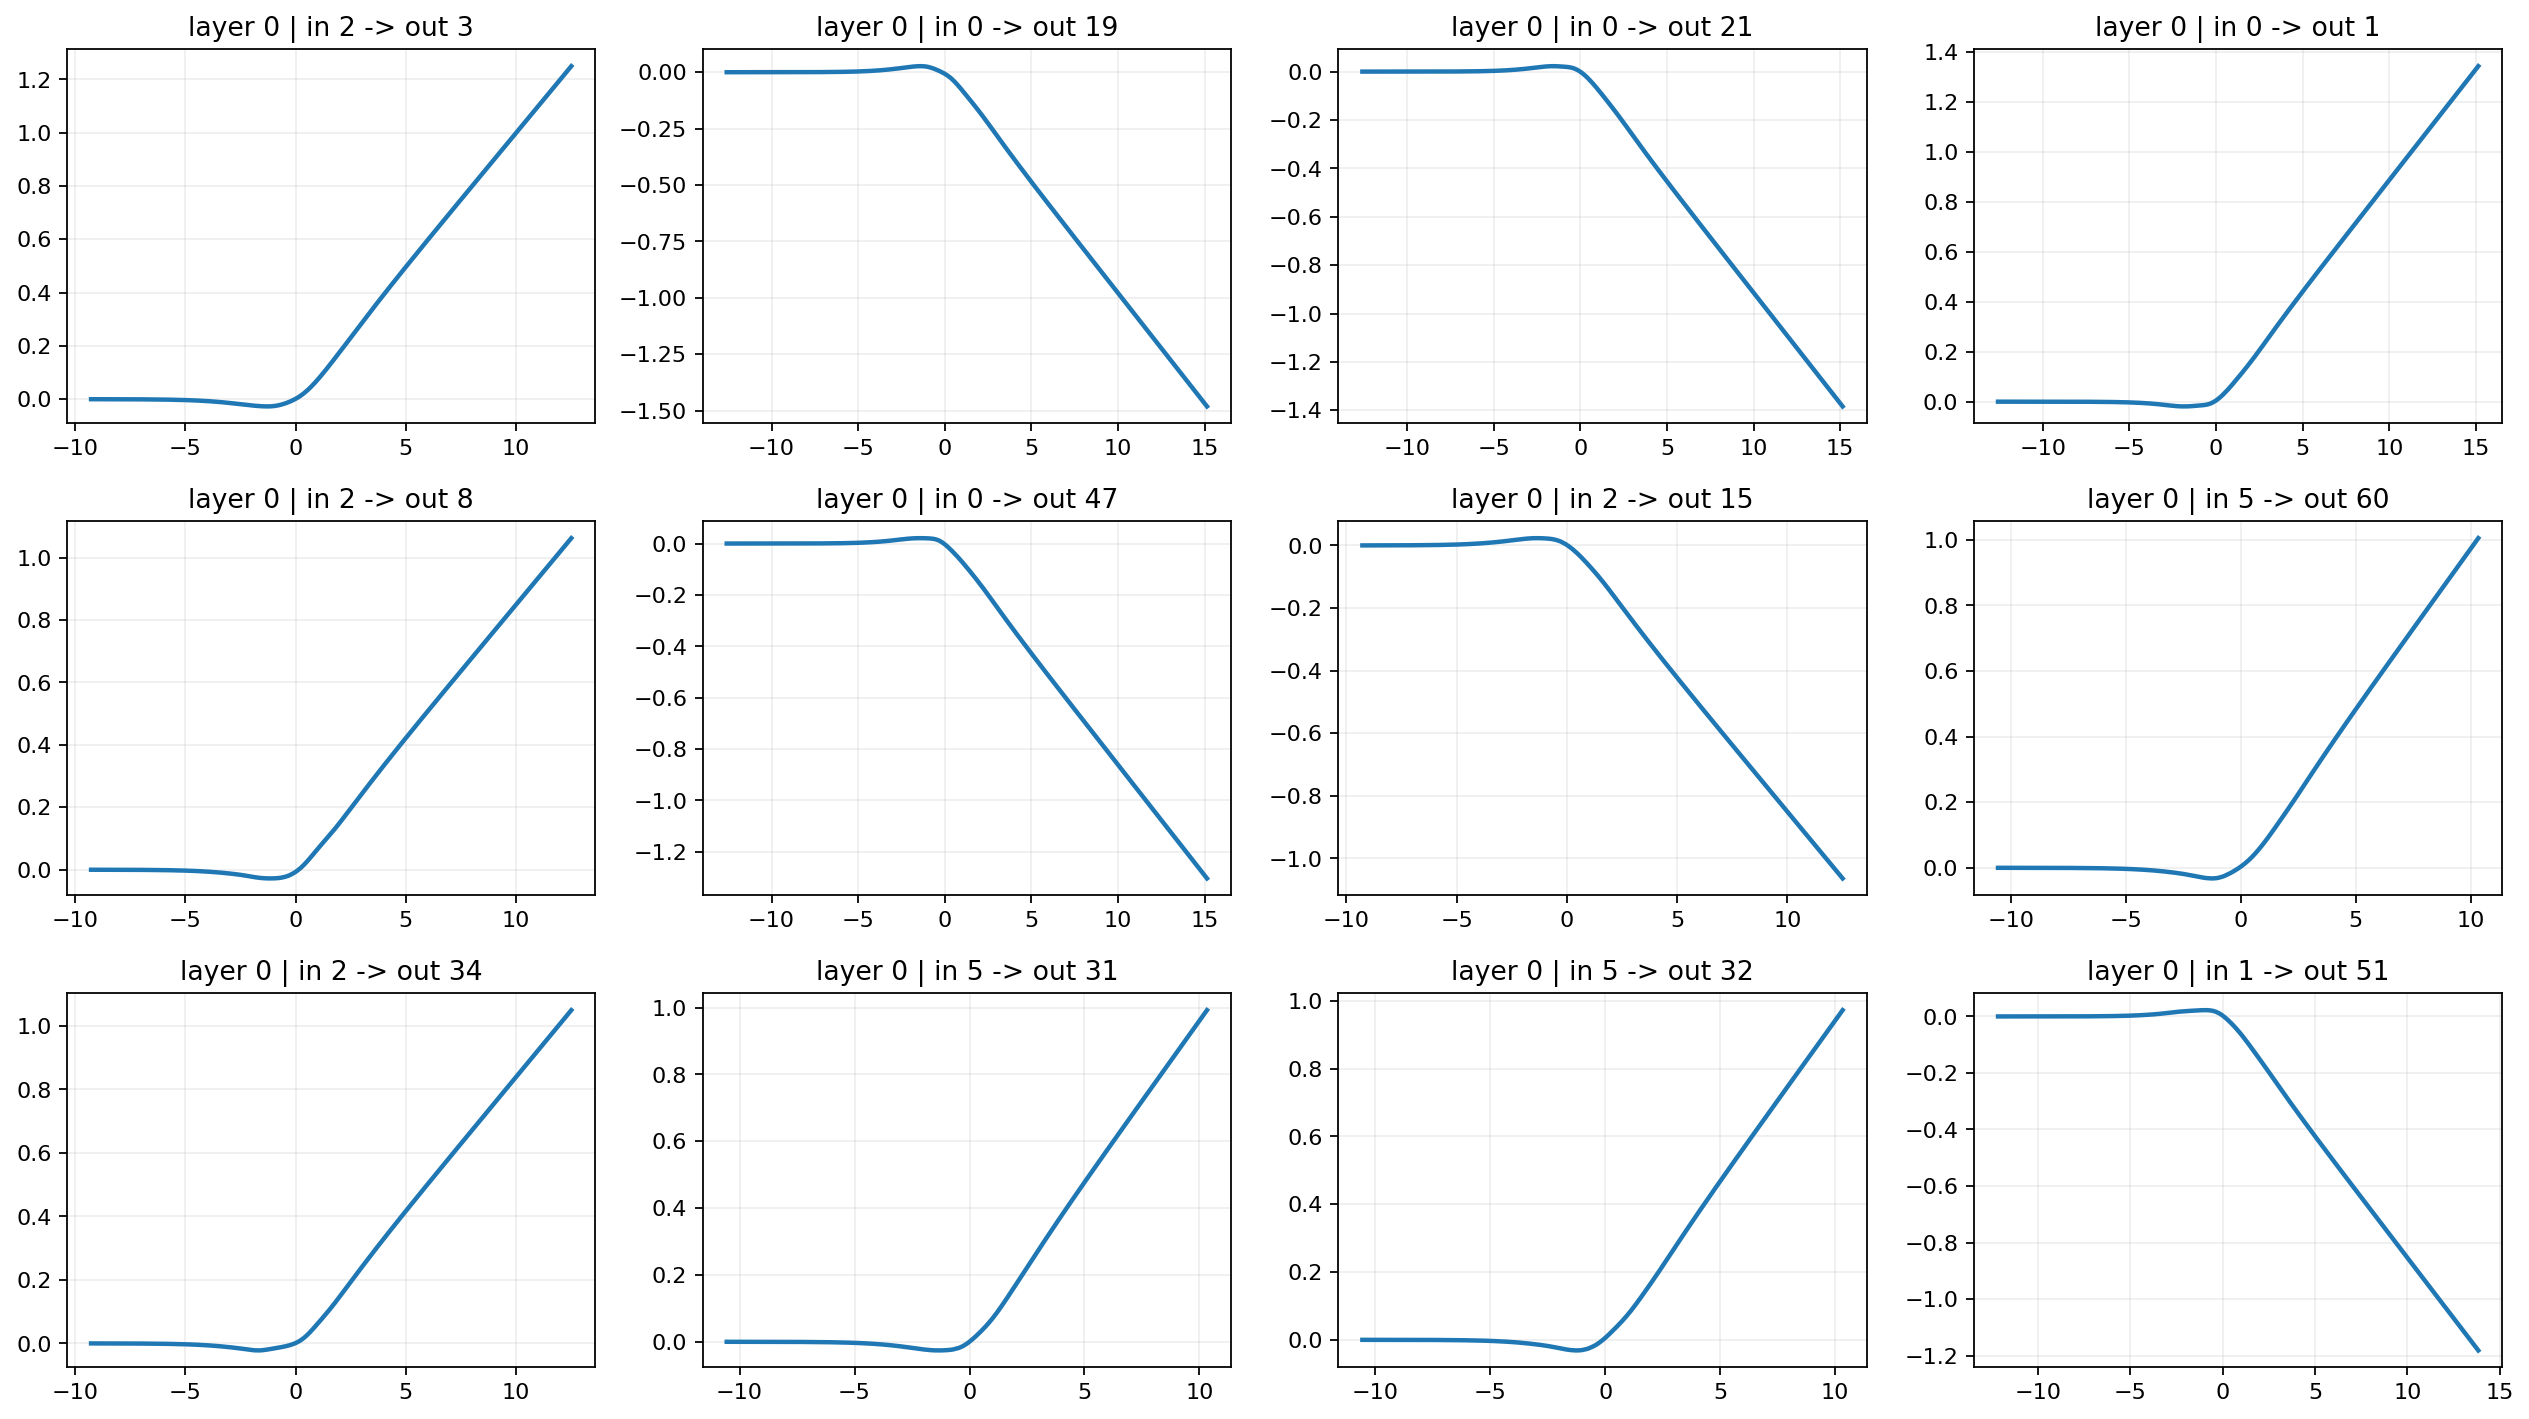


Resumen artefactos:
- Sproud CSV: G:\Cosas_programacion\Breast Cancer Interpretable-ml\Prueba_emmbedings\artifacts\sproud_edges.csv
- Symbolic CSV: G:\Cosas_programacion\Breast Cancer Interpretable-ml\Prueba_emmbedings\artifacts\symbolic_edges.csv
- Formula TXT: G:\Cosas_programacion\Breast Cancer Interpretable-ml\Prueba_emmbedings\artifacts\symbolic_formula.txt
- Plot PNG: G:\Cosas_programacion\Breast Cancer Interpretable-ml\Prueba_emmbedings\artifacts\sproud_edges_layer0.png | existe: True


In [12]:
# Sproud + simbólico + fórmula + gráfica (con validaciones explícitas)
from IPython.display import Image, display as ipy_display

sproud_df = sproud_importance(kan_model, layer=SPROUD_LAYER, top_k=SPROUD_TOP_K)
sproud_df.to_csv(SPROUD_OUT, index=False)
print("Sproud edges:", SPROUD_OUT)
display(sproud_df)

symbolic_df = symbolic_fit_for_edges(
    kan_model,
    sproud_df,
    layer=SPROUD_LAYER,
    topk=SYMBOLIC_CANDIDATES,
    r2_threshold=SYMBOLIC_R2_THRESHOLD,
    lib=SYMBOLIC_LIB,
    max_seconds=SYMBOLIC_MAX_SECONDS,
)

# Evitar considerar como éxito ajustes triviales (best_symbolic==0 y r2==0)
if not symbolic_df.empty:
    symbolic_df["is_trivial"] = (
        symbolic_df["best_symbolic"].astype(str).isin(["0", "0.0", "None"]) &
        symbolic_df["best_r2"].fillna(0.0).le(0.0)
    )
else:
    symbolic_df["is_trivial"] = []

symbolic_df.to_csv(SYMBOLIC_OUT, index=False)
print("Symbolic edges:", SYMBOLIC_OUT)
display(symbolic_df)

all_trivial = bool((not symbolic_df.empty) and symbolic_df["is_trivial"].all())
if RUN_AUTO_SYMBOLIC_FALLBACK and all_trivial and hasattr(kan_model, "auto_symbolic"):
    print("\nAjuste local trivial detectado. Ejecutando fallback con auto_symbolic()...")
    try:
        kan_model.auto_symbolic(lib=SYMBOLIC_LIB, verbose=0, weight_simple=0.5, r2_threshold=0.0)
        print("auto_symbolic() ejecutado correctamente")
    except Exception as e:
        print("auto_symbolic() falló:", repr(e))
elif all_trivial:
    print("\nAjuste trivial detectado, pero se omite auto_symbolic para evitar tiempos muy largos.")
    print("Si lo quieres, pon RUN_AUTO_SYMBOLIC_FALLBACK=True y vuelve a ejecutar esta celda.")

# Fórmula global (si está disponible)
try:
    vars_ = [f"z_{i}" for i in range(int(kan_model.width_in[0]))]
    formula = kan_model.symbolic_formula(var=vars_)
    formula_txt = str(formula)
except Exception as e:
    formula_txt = f"No se pudo extraer symbolic_formula(): {repr(e)}"

FORMULA_OUT.write_text(formula_txt, encoding="utf-8")
print("Formula simbólica guardada en:", FORMULA_OUT)
print("\nPreview formula (primeros 1500 chars):")
print(formula_txt[:1500])

# Gráfica opcional + render inline
try:
    plot_path, pairs = save_kan_edges_light(
        kan_model,
        output_path=PLOT_OUT,
        layer=SPROUD_LAYER,
        top_k=SPROUD_TOP_K,
        metric="mean_abs",
        sample_points=False,
    )
    print("\nGráfico guardado en:", plot_path)
    print("Aristas graficadas:", pairs)
    ipy_display(Image(filename=str(plot_path)))
except Exception as e:
    print("\nNo se pudo generar gráfica de aristas:", repr(e))
    print("Se conserva salida simbólica en:", FORMULA_OUT)

print("\nResumen artefactos:")
print("- Sproud CSV:", SPROUD_OUT)
print("- Symbolic CSV:", SYMBOLIC_OUT)
print("- Formula TXT:", FORMULA_OUT)
print("- Plot PNG:", PLOT_OUT, "| existe:", PLOT_OUT.exists())